<a href="https://colab.research.google.com/github/Adesaputra4006/PJBL_AnReg/blob/main/Analisis_Regresi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Nama : Ade saputra
#Nim : 2430109040006

##Import Packages & Data Loading

In [20]:
import pandas as pd
from scipy.stats import zscore, pearsonr, shapiro
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import linregress
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

data = pd.read_csv("/content/Data fix.csv")


df = data[["Stress Level","Quality of Sleep"]]

print("HEAD DATA:")
print(df.head())

print("\nTAIL DATA:")
print(df.tail())

HEAD DATA:
   Stress Level  Quality of Sleep
0             6                 6
1             8                 6
2             8                 6
3             8                 4
4             8                 4

TAIL DATA:
     Stress Level  Quality of Sleep
369             3                 9
370             3                 9
371             3                 9
372             3                 9
373             3                 9


##Pembersihan Data, Deteksi Outlier, dan Statistik Deskriptif

In [21]:
# PEMBERSIHAN DATA

print("\n=== MISSING VALUE ===")
print(df.isnull().sum())
print("Total missing:", df.isnull().sum().sum())

df = df.dropna()  # hapus missing value

# DETEKSI OUTLIER
def detect_outliers(series):
    x = series.dropna()

    # IQR Method
    Q1 = x.quantile(0.25)
    Q3 = x.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers_iqr = x[(x < lower) | (x > upper)]

    # Z-Score
    z = zscore(x)
    outliers_z = x[np.abs(z) > 3]

    return outliers_iqr, outliers_z, lower, upper


print("\n=== DETEKSI OUTLIER ===")
for col in df.columns:
    out_iqr, out_z, low, up = detect_outliers(df[col])
    print(f"\nAnalisis Outlier untuk: {col}")
    print("Outlier IQR:", len(out_iqr))
    print("Outlier Z-Score:", len(out_z))
    print("Batas bawah:", round(low,2))
    print("Batas atas:", round(up,2))
    if len(out_iqr) > 0:
        print("Contoh nilai outlier:", out_iqr.unique()[:5])



print("\n=== STATISTIK DESKRIPTIF ===")
print(df.describe())


=== MISSING VALUE ===
Stress Level        0
Quality of Sleep    0
dtype: int64
Total missing: 0

=== DETEKSI OUTLIER ===

Analisis Outlier untuk: Stress Level
Outlier IQR: 0
Outlier Z-Score: 0
Batas bawah: -0.5
Batas atas: 11.5

Analisis Outlier untuk: Quality of Sleep
Outlier IQR: 0
Outlier Z-Score: 0
Batas bawah: 3.0
Batas atas: 11.0

=== STATISTIK DESKRIPTIF ===
       Stress Level  Quality of Sleep
count    374.000000        374.000000
mean       5.385027          7.312834
std        1.774526          1.196956
min        3.000000          4.000000
25%        4.000000          6.000000
50%        5.000000          7.000000
75%        7.000000          8.000000
max        8.000000          9.000000


## Cek Korelasi(Korelasi Pearson)

0    6
1    8
2    8
3    8
4    8
Name: Stress Level, dtype: int64
0    6
1    6
2    6
3    4
4    4
Name: Quality of Sleep, dtype: int64

Koefisien Korelasi Pearson antara Stress Level dan Quality of Sleep: -0.899
Interpretasi: Korelasi sangat kuat negatif


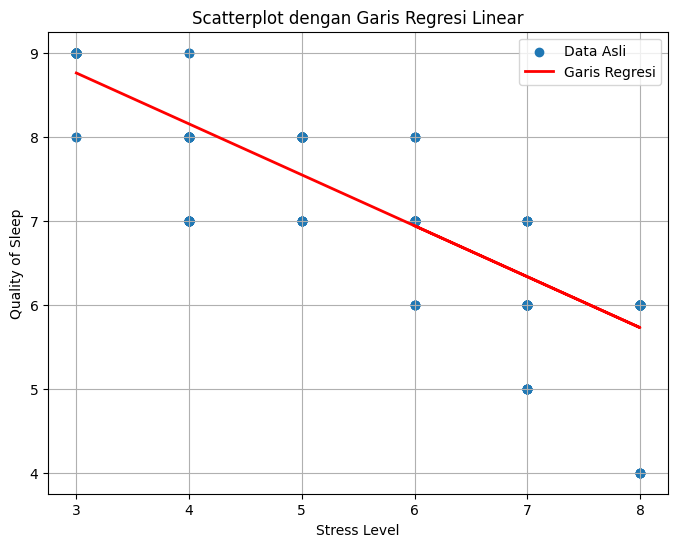

Koefisien Korelasi Pearson: -0.899
P-value: 0.000000
Tingkat Signifikansi (alpha): 0.05

Keputusan: Tolak Hipotesis Nol (H0)
Interpretasi Uji: Ada bukti statistik yang cukup untuk menyimpulkan adanya hubungan linier yang signifikan antara Stress Level dan Quality of Sleep dalam populasi.


In [22]:
variabel_x = df["Stress Level"]
variabel_y = df["Quality of Sleep"]
print(variabel_x.head())
print(variabel_y.head())

# Hitung koefisien korelasi Pearson
korelasi_pearson, p_value = pearsonr(variabel_x, variabel_y)
print(f"\nKoefisien Korelasi Pearson antara Stress Level dan Quality of Sleep: {korelasi_pearson:.3f}")

# Interpretasi hasil
if korelasi_pearson > 0.8:
    interpretasi = "Korelasi sangat kuat positif"
elif korelasi_pearson > 0.6:
    interpretasi = "Korelasi kuat positif"
elif korelasi_pearson > 0.4:
    interpretasi = "Korelasi sedang positif"
elif korelasi_pearson > 0.2:
    interpretasi = "Korelasi lemah positif"
elif korelasi_pearson > 0:
    interpretasi = "Korelasi sangat lemah positif"
elif korelasi_pearson < -0.8:
    interpretasi = "Korelasi sangat kuat negatif"
elif korelasi_pearson < -0.6:
    interpretasi = "Korelasi kuat negatif"
elif korelasi_pearson < -0.4:
    interpretasi = "Korelasi sedang negatif"
elif korelasi_pearson < -0.2:
    interpretasi = "Korelasi lemah negatif"
elif korelasi_pearson < 0:
    interpretasi = "Korelasi sangat lemah negatif"
else:
    interpretasi = "Tidak ada korelasi linier (atau sangat mendekati nol)"

print(f"Interpretasi: {interpretasi}")

# Buat scatterplot
# Hitung parameter regresi linear
hasil_regresi = linregress(variabel_x, variabel_y)
slope = hasil_regresi.slope
intercept = hasil_regresi.intercept

# Buat prediksi Y berdasarkan garis regresi
y_pred = slope * variabel_x + intercept

# Plot scatter baru + garis regresi
plt.figure(figsize=(8, 6))
plt.scatter(variabel_x, variabel_y, label="Data Asli")
plt.plot(variabel_x, y_pred, color='red', linewidth=2, label="Garis Regresi")

plt.xlabel("Stress Level")
plt.ylabel("Quality of Sleep")
plt.title("Scatterplot dengan Garis Regresi Linear")
plt.legend()
plt.grid(True)
plt.show()


# Hitung koefisien korelasi Pearson dan p-value
korelasi_pearson, p_value = pearsonr(variabel_x, variabel_y)
# Tetapkan tingkat signifikansi (alpha)
alpha = 0.05
print(f"Koefisien Korelasi Pearson: {korelasi_pearson:.3f}")
print(f"P-value: {p_value:.6f}")
print(f"Tingkat Signifikansi (alpha): {alpha}")
# Lakukan uji hipotesis
if p_value < alpha:
    keputusan = "Tolak Hipotesis Nol (H0)"
    interpretasi_uji = "Ada bukti statistik yang cukup untuk menyimpulkan adanya hubungan linier yang signifikan antara Stress Level dan Quality of Sleep dalam populasi."
else:
    keputusan = "Gagal Menolak Hipotesis Nol (H0)"
    interpretasi_uji = "Tidak ada bukti statistik yang cukup untuk menyimpulkan adanya hubungan linier yang signifikan Stress Level dan Quality of Sleep dalam populasi."
print(f"\nKeputusan: {keputusan}")
print(f"Interpretasi Uji: {interpretasi_uji}")

##Model Regresi

In [23]:

X = df["Stress Level"]
Y = df["Quality of Sleep"]

X_reg = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

print(model.summary())

print("\nPersamaan regresi:")
print(f"Quality of Sleep = {intercept:.3f} + {slope:.3f} Stress Level")

                                 OLS Regression Results                                
Dep. Variable:       Quality of Sleep   R-squared (uncentered):                   0.796
Model:                            OLS   Adj. R-squared (uncentered):              0.795
Method:                 Least Squares   F-statistic:                              1454.
Date:                Tue, 31 Mar 2026   Prob (F-statistic):                   9.07e-131
Time:                        14:42:41   Log-Likelihood:                         -982.58
No. Observations:                 374   AIC:                                      1967.
Df Residuals:                     373   BIC:                                      1971.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

##Uji Asumsi

=== Uji Normalitas (Shapiro-Wilk) ===
p-value: 6.65734970272589e-19
Kesimpulan: Residual TIDAK berdistribusi normal


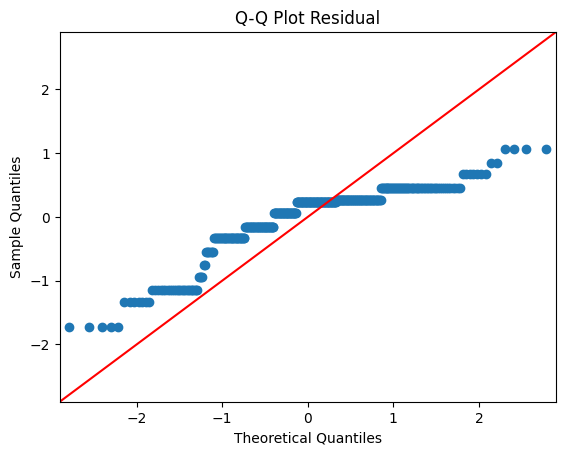


=== Uji Homoskedastisitas (Breusch-Pagan) ===
p-value: 0.23112098143072263
Kesimpulan: Tidak terjadi heteroskedastisitas


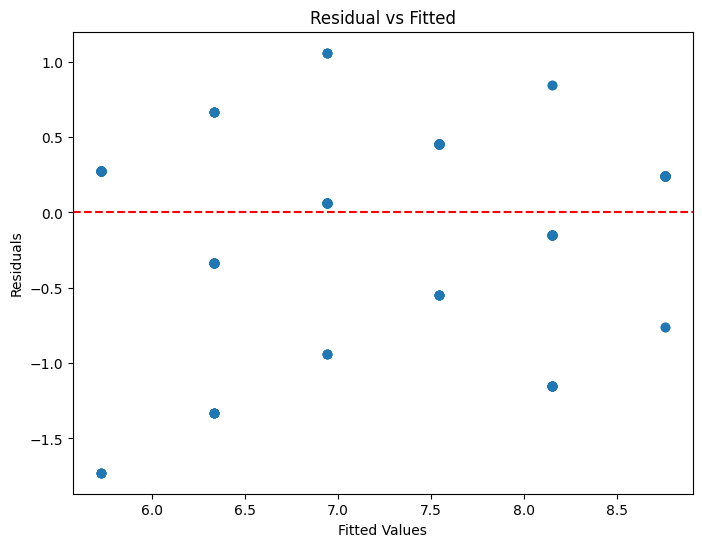


=== Uji Autokorelasi (Durbin-Watson) ===
Nilai Durbin-Watson: 0.8537332038026159
Kesimpulan: Ada autokorelasi positif


In [24]:
residuals = Y - y_pred

# 1. UJI NORMALITAS (Shapiro-Wilk)
stat, p = shapiro(residuals)

print("=== Uji Normalitas (Shapiro-Wilk) ===")
print("p-value:", p)

if p > 0.05:
    print("Kesimpulan: Residual berdistribusi normal")
else:
    print("Kesimpulan: Residual TIDAK berdistribusi normal")

# ================================
# Q-Q PLOT (Visualisasi Normalitas)
# ================================
sm.qqplot(residuals, line='45')
plt.title("Q-Q Plot Residual")
plt.show()

# 2. UJI HOMOSKEDASTISITAS (Breusch-Pagan)

X_sm = sm.add_constant(variabel_x)
model_sm = sm.OLS(variabel_y, X_sm).fit()

bp_test = het_breuschpagan(model_sm.resid, model_sm.model.exog)

print("\n=== Uji Homoskedastisitas (Breusch-Pagan) ===")
print("p-value:", bp_test[1])

if bp_test[1] > 0.05:
    print("Kesimpulan: Tidak terjadi heteroskedastisitas")
else:
    print("Kesimpulan: Terjadi heteroskedastisitas")


# RESIDUAL vs FITTED PLOT

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual vs Fitted")
plt.show()


# 3. UJI AUTOKORELASI (Durbin-Watson)

dw = durbin_watson(residuals)

print("\n=== Uji Autokorelasi (Durbin-Watson) ===")
print("Nilai Durbin-Watson:", dw)

if 1.5 < dw < 2.5:
    print("Kesimpulan: Tidak ada autokorelasi")
elif dw <= 1.5:
    print("Kesimpulan: Ada autokorelasi positif")
else:
    print("Kesimpulan: Ada autokorelasi negatif")

##Koefisien Determinasi

In [25]:
r_squared = model.rsquared

print("\nKoefisien Determinasi (R²):", round(r_squared,4))
print("Artinya", round(r_squared*100,2),"% variasi kualitas tidur dijelaskan oleh stress level")


Koefisien Determinasi (R²): 0.7959
Artinya 79.59 % variasi kualitas tidur dijelaskan oleh stress level
